# Ensemble Methods & Hyperparameter Tuning
**Credit Risk Dataset — Practice Notebook**

Covers: Bagging · Boosting · Stacking · Voting · Log Loss · ROC-AUC · Random Search · Genetic Algorithm · Bayesian Optimisation

## 1. Imports

In [6]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import random
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, BaggingClassifier,
    GradientBoostingClassifier, StackingClassifier, VotingClassifier
)
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, log_loss, classification_report,
    precision_score, recall_score
)
from scipy.stats import randint
import matplotlib.pyplot as plt
import sys
print(sys.executable)

from skopt import gp_minimize
from skopt.space import Integer
from skopt.utils import use_named_args
# Bayesian optimisation — install with:
# c:\Users\Kasia\AppData\Local\Programs\Python\Python311\python.exe -m pip install hyperopt
#from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval

pd.set_option("display.max_columns", None)


c:\Users\Kasia\AppData\Local\Programs\Python\Python311\python.exe


## 2. Load & Prepare Data

In [7]:
# ── paths ──────────────────────────────────────────────────────────────────
REPO_ROOT  = Path(r"F:\Apps\Credit-Risk-Score-ML")
DATA_PATH  = REPO_ROOT / "data" / "raw" / "default of credit card clients.xls"
RANDOM_STATE = 42

print("Data path:", DATA_PATH)
print("Exists:   ", DATA_PATH.exists())


Data path: F:\Apps\Credit-Risk-Score-ML\data\raw\default of credit card clients.xls
Exists:    True


In [8]:
df_raw = pd.read_excel(DATA_PATH, sheet_name=0, engine="xlrd", header=1)
df = df_raw.rename(columns={"default payment next month": "DEFAULT_NEXT_MONTH"})

# fix undocumented category codes
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
df["MARRIAGE"]  = df["MARRIAGE"].replace({0: 3})

print("Shape:", df.shape)
print("\nTarget distribution (%):")
print((df["DEFAULT_NEXT_MONTH"].value_counts(normalize=True) * 100).round(2))


Shape: (30000, 25)

Target distribution (%):
DEFAULT_NEXT_MONTH
0    77.88
1    22.12
Name: proportion, dtype: float64


In [9]:
# ── features & target ───────────────────────────────────────────────────────
TARGET = "DEFAULT_NEXT_MONTH"

# Drop ID — not a predictive feature
X = df.drop(columns=["ID", TARGET], errors="ignore")
y = df[TARGET].astype(int)

# One-hot encode the three categorical columns
X = pd.get_dummies(X, columns=["SEX", "EDUCATION", "MARRIAGE"], drop_first=True)

# Train / test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale — important for KNN, SVM, Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Train:", X_train.shape, "  Test:", X_test.shape)
print("Default rate — train:", y_train.mean().round(4),
      "  test:", y_test.mean().round(4))


Train: (24000, 26)   Test: (6000, 26)
Default rate — train: 0.2212   test: 0.2212


## 3. Evaluation Helper
The dataset is imbalanced (~22 % default), so **ROC-AUC and F1** are better measures than accuracy alone.

In [11]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name, scaled=False):
    
    model.fit(X_tr, y_tr)
    preds  = model.predict(X_te)
    probs  = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

    acc  = accuracy_score(y_te, preds)
    f1   = f1_score(y_te, preds, average="macro")
    auc  = roc_auc_score(y_te, probs) if probs is not None else None

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Macro-F1  : {f1:.4f}")
    if auc:
        print(f"  ROC-AUC   : {auc:.4f}")
    print(classification_report(y_te, preds, target_names=["No Default", "Default"]))
    return auc or acc


## 4. Bagging
Trains multiple KNN models on random data subsets and aggregates predictions.
class_weight is not available in BaggingClassifier directly, but we handle imbalance via the base estimator where possible.

In [12]:
base_knn = KNeighborsClassifier(n_neighbors=5)

bagging_knn = BaggingClassifier(
    estimator=base_knn,
    n_estimators=30,
    random_state=RANDOM_STATE
)

# KNN needs scaled data
evaluate_model(bagging_knn, X_train_sc, y_train, X_test_sc, y_test, "Bagging — KNN (scaled)")



  Bagging — KNN (scaled)
  Accuracy  : 0.7960
  Macro-F1  : 0.6509
  ROC-AUC   : 0.7140
              precision    recall  f1-score   support

  No Default       0.83      0.92      0.88      4673
     Default       0.56      0.34      0.43      1327

    accuracy                           0.80      6000
   macro avg       0.70      0.63      0.65      6000
weighted avg       0.77      0.80      0.78      6000



0.7139657810723341

In [13]:
# Try bagging on Logistic Regression — handles imbalance with class_weight
base_lr = LogisticRegression(max_iter=1000, class_weight="balanced")

bagging_lr = BaggingClassifier(
    estimator=base_lr,
    n_estimators=30,
    random_state=RANDOM_STATE
)

evaluate_model(bagging_lr, X_train_sc, y_train, X_test_sc, y_test, "Bagging — Logistic Regression (scaled)")



  Bagging — Logistic Regression (scaled)
  Accuracy  : 0.6780
  Macro-F1  : 0.6165
  ROC-AUC   : 0.7109
              precision    recall  f1-score   support

  No Default       0.87      0.69      0.77      4673
     Default       0.37      0.63      0.46      1327

    accuracy                           0.68      6000
   macro avg       0.62      0.66      0.62      6000
weighted avg       0.76      0.68      0.70      6000



0.7109388039582195

## 5. Boosting
### 5a. XGBoost

In [14]:
# scale_pos_weight handles class imbalance in XGBoost
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {spw:.2f}  (neg/pos ratio)")

xgb_model = xgb.XGBClassifier(
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    scale_pos_weight=spw
)

evaluate_model(xgb_model, X_train, y_train, X_test, y_test, "XGBoost")


scale_pos_weight = 3.52  (neg/pos ratio)

  XGBoost
  Accuracy  : 0.7588
  Macro-F1  : 0.6769
  ROC-AUC   : 0.7572
              precision    recall  f1-score   support

  No Default       0.87      0.81      0.84      4673
     Default       0.46      0.58      0.51      1327

    accuracy                           0.76      6000
   macro avg       0.67      0.69      0.68      6000
weighted avg       0.78      0.76      0.77      6000



0.7572461273221996

### 5b. Gradient Boosting

In [15]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)

evaluate_model(gb_model, X_train, y_train, X_test, y_test, "Gradient Boosting")



  Gradient Boosting
  Accuracy  : 0.8185
  Macro-F1  : 0.6788
  ROC-AUC   : 0.7801
              precision    recall  f1-score   support

  No Default       0.84      0.95      0.89      4673
     Default       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



0.780092906531791

## 6. Stacking
Two base learners feed into a Logistic Regression meta-model.

In [16]:
base_models = [
    ("rf",  RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE)),
    ("xgb", xgb.XGBClassifier(eval_metric="logloss", scale_pos_weight=spw, random_state=RANDOM_STATE)),
]
meta_model = LogisticRegression(max_iter=1000, class_weight="balanced")

stack_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model)
evaluate_model(stack_clf, X_train, y_train, X_test, y_test, "Stacking — RF + XGB → LR")



  Stacking — RF + XGB → LR
  Accuracy  : 0.7530
  Macro-F1  : 0.6782
  ROC-AUC   : 0.7654
              precision    recall  f1-score   support

  No Default       0.88      0.79      0.83      4673
     Default       0.46      0.61      0.52      1327

    accuracy                           0.75      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.78      0.75      0.76      6000



0.7653543234708972

## 7. Voting Ensemble
### 7a. Hard Voting

In [17]:
clf_lr  = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
clf_rf  = RandomForestClassifier(n_estimators=50, class_weight="balanced", random_state=RANDOM_STATE)
clf_gnb = GaussianNB()

hard_voting = VotingClassifier(
    estimators=[("lr", clf_lr), ("rf", clf_rf), ("gnb", clf_gnb)],
    voting="hard"
)

evaluate_model(hard_voting, X_train_sc, y_train, X_test_sc, y_test, "Hard Voting — LR + RF + GNB")



  Hard Voting — LR + RF + GNB
  Accuracy  : 0.7277
  Macro-F1  : 0.6524
              precision    recall  f1-score   support

  No Default       0.87      0.77      0.81      4673
     Default       0.42      0.59      0.49      1327

    accuracy                           0.73      6000
   macro avg       0.64      0.68      0.65      6000
weighted avg       0.77      0.73      0.74      6000



0.7276666666666667

### 7b. Soft Voting
Averages predicted probabilities — generally better than hard voting when models are calibrated.

In [18]:
soft_voting = VotingClassifier(
    estimators=[("lr", clf_lr), ("rf", clf_rf), ("gnb", clf_gnb)],
    voting="soft"
)

evaluate_model(soft_voting, X_train_sc, y_train, X_test_sc, y_test, "Soft Voting — LR + RF + GNB")



  Soft Voting — LR + RF + GNB
  Accuracy  : 0.7683
  Macro-F1  : 0.6782
  ROC-AUC   : 0.7429
              precision    recall  f1-score   support

  No Default       0.86      0.83      0.85      4673
     Default       0.48      0.54      0.51      1327

    accuracy                           0.77      6000
   macro avg       0.67      0.69      0.68      6000
weighted avg       0.78      0.77      0.77      6000



0.7428552261375494

## 8. Log Loss
Measures how well predicted probabilities match true labels. Lower is better.

In [19]:
lr_for_loss = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_for_loss.fit(X_train_sc, y_train)
y_prob_lr = lr_for_loss.predict_proba(X_test_sc)

loss_lr = log_loss(y_test, y_prob_lr)
print(f"Log Loss — Logistic Regression : {loss_lr:.4f}")

# Compare with XGBoost
xgb_model.fit(X_train, y_train)
y_prob_xgb = xgb_model.predict_proba(X_test)
loss_xgb = log_loss(y_test, y_prob_xgb)
print(f"Log Loss — XGBoost             : {loss_xgb:.4f}")


Log Loss — Logistic Regression : 0.6071
Log Loss — XGBoost             : 0.5253


## 9. ROC Curve — Multiple Models

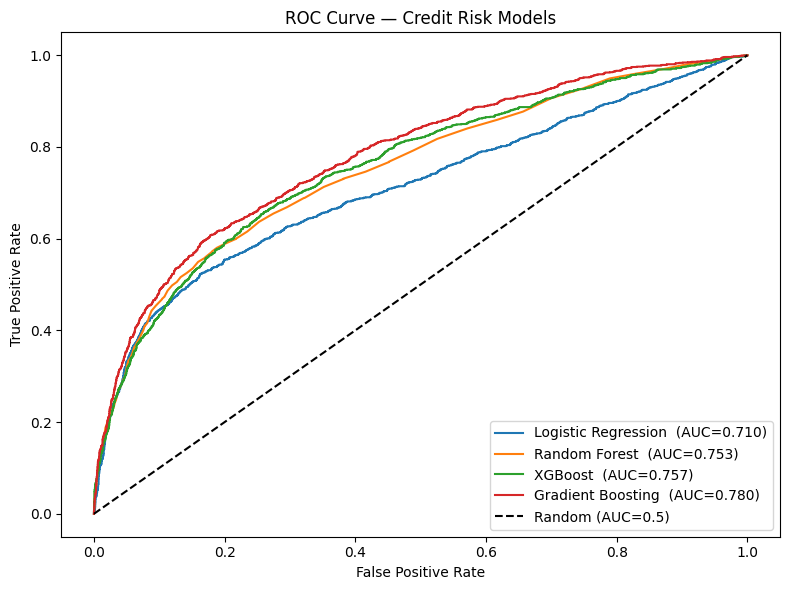

In [20]:
models_for_roc = {
    "Logistic Regression": (lr_for_loss,  X_test_sc),
    "Random Forest"      : (RandomForestClassifier(n_estimators=100, class_weight="balanced",
                             random_state=RANDOM_STATE).fit(X_train, y_train), X_test),
    "XGBoost"            : (xgb_model, X_test),
    "Gradient Boosting"  : (gb_model,  X_test),
}

plt.figure(figsize=(8, 6))
for name, (mdl, Xte) in models_for_roc.items():
    y_prob = mdl.predict_proba(Xte)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name}  (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Credit Risk Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 10. Hyperparameter Tuning
### 10a. Random Search — Random Forest

In [21]:
rf = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE)

param_dist = {
    "n_estimators"     : randint(50, 301),
    "max_depth"        : randint(2, 21),
    "min_samples_split": randint(2, 11),
    "min_samples_leaf" : randint(1, 6),
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="roc_auc",      # AUC is a better scoring metric than accuracy here
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

random_search.fit(X_train, y_train)

print("Best params (Random Search):")
print(random_search.best_params_)
print("Best CV ROC-AUC:", round(random_search.best_score_, 4))

evaluate_model(random_search.best_estimator_, X_train, y_train, X_test, y_test,
               "Random Search — Best RF")


Best params (Random Search):
{'max_depth': 11, 'min_samples_leaf': 4, 'min_samples_split': 7, 'n_estimators': 270}
Best CV ROC-AUC: 0.7814

  Random Search — Best RF
  Accuracy  : 0.7910
  Macro-F1  : 0.7044
  ROC-AUC   : 0.7753
              precision    recall  f1-score   support

  No Default       0.87      0.86      0.86      4673
     Default       0.53      0.56      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.71      0.70      6000
weighted avg       0.80      0.79      0.79      6000



0.7753072009657687

### 10b. Genetic Algorithm
Evolutionary search: generate population → evaluate fitness → select parents → crossover → mutate → repeat.

In [22]:
param_space = {
    "n_estimators"     : (50, 200),
    "max_depth"        : (2, 20),
    "min_samples_split": (2, 10),
    "min_samples_leaf" : (1, 5),
}

def create_individual():
    return {k: random.randint(v[0], v[1]) for k, v in param_space.items()}

def create_population(pop_size):
    return [create_individual() for _ in range(pop_size)]

def fitness_function(individual):
    model = RandomForestClassifier(
        **individual,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

def evaluate_population(population):
    return [(ind, fitness_function(ind)) for ind in population]

def selection(scored_pop, num_parents):
    scored_pop = sorted(scored_pop, key=lambda x: x[1], reverse=True)
    return [ind for ind, _ in scored_pop[:num_parents]]

def crossover(p1, p2):
    return {k: random.choice([p1[k], p2[k]]) for k in p1}

def mutation(individual, rate=0.1):
    mutated = individual.copy()
    for k, (lo, hi) in param_space.items():
        if random.random() < rate:
            mutated[k] = random.randint(lo, hi)
    return mutated


In [23]:
def genetic_algorithm(pop_size=10, generations=5, num_parents=4, mutation_rate=0.2):
    population  = create_population(pop_size)
    best_ind, best_score = None, -1

    for gen in range(generations):
        scored = evaluate_population(population)
        scored = sorted(scored, key=lambda x: x[1], reverse=True)

        cur_ind, cur_score = scored[0]
        print(f"Generation {gen+1}  |  best AUC: {cur_score:.4f}  |  params: {cur_ind}")

        if cur_score > best_score:
            best_score, best_ind = cur_score, cur_ind

        parents = selection(scored, num_parents)
        next_pop = parents.copy()
        while len(next_pop) < pop_size:
            child = crossover(random.choice(parents), random.choice(parents))
            next_pop.append(mutation(child, mutation_rate))
        population = next_pop

    return best_ind, best_score

best_params_ga, best_cv_auc_ga = genetic_algorithm(pop_size=10, generations=5)
print("\nBest params (GA):", best_params_ga)
print("Best CV AUC     :", round(best_cv_auc_ga, 4))


Generation 1  |  best AUC: 0.7781  |  params: {'n_estimators': 116, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 5}
Generation 2  |  best AUC: 0.7783  |  params: {'n_estimators': 116, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 5}
Generation 3  |  best AUC: 0.7783  |  params: {'n_estimators': 116, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 5}
Generation 4  |  best AUC: 0.7783  |  params: {'n_estimators': 165, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 5}
Generation 5  |  best AUC: 0.7789  |  params: {'n_estimators': 165, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 5}

Best params (GA): {'n_estimators': 165, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 5}
Best CV AUC     : 0.7789


In [24]:
ga_model = RandomForestClassifier(
    **best_params_ga,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
evaluate_model(ga_model, X_train, y_train, X_test, y_test, "Genetic Algorithm — Best RF")



  Genetic Algorithm — Best RF
  Accuracy  : 0.7947
  Macro-F1  : 0.7050
  ROC-AUC   : 0.7735
              precision    recall  f1-score   support

  No Default       0.87      0.86      0.87      4673
     Default       0.53      0.55      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.71      0.70      6000
weighted avg       0.80      0.79      0.80      6000



0.7735283147056372

### 10c. Bayesian Optimisation (hyperopt)
Uses a probabilistic model to pick the next parameters to try — more efficient than random search.

In [26]:
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

# ── Bayesian Optimisation with skopt ──────────────────────────────────────
search_spaces = {
    "n_estimators"     : Integer(50, 200),
    "max_depth"        : Integer(2, 20),
    "min_samples_split": Integer(2, 10),
    "min_samples_leaf" : Integer(1, 5),
}

bayes_search = BayesSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    search_spaces=search_spaces,
    n_iter=30,
    cv=5,
    scoring="roc_auc",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

bayes_search.fit(X_train, y_train)

print("Best params (Bayesian):")
print(bayes_search.best_params_)
print("Best CV ROC-AUC:", round(bayes_search.best_score_, 4))


Best params (Bayesian):
OrderedDict([('max_depth', 16), ('min_samples_leaf', 5), ('min_samples_split', 10), ('n_estimators', 159)])
Best CV ROC-AUC: 0.7816


In [27]:
bo_model = bayes_search.best_estimator_
evaluate_model(bo_model, X_train, y_train, X_test, y_test, "Bayesian Optimisation — Best RF")



  Bayesian Optimisation — Best RF
  Accuracy  : 0.7995
  Macro-F1  : 0.7065
  ROC-AUC   : 0.7729
              precision    recall  f1-score   support

  No Default       0.87      0.87      0.87      4673
     Default       0.55      0.54      0.54      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.70      0.71      6000
weighted avg       0.80      0.80      0.80      6000



0.7728970527833015

## 11. Summary Comparison

In [28]:
# Re-run all tuned models and collect ROC-AUC for comparison
summary_models = {
    "Bagging (LR)"         : (bagging_lr,  X_test_sc),
    "XGBoost"              : (xgb_model,   X_test),
    "Gradient Boosting"    : (gb_model,    X_test),
    "Stacking RF+XGB->LR"  : (stack_clf,   X_test),
    "Soft Voting"          : (soft_voting,  X_test_sc),
    "Random Search RF"     : (random_search.best_estimator_, X_test),
    "Genetic Algorithm RF" : (ga_model,    X_test),
    "Bayesian Optimised RF": (bo_model,    X_test),
}

results = []
for name, (mdl, Xte) in summary_models.items():
    y_prob = mdl.predict_proba(Xte)[:, 1]
    y_pred = mdl.predict(Xte)
    results.append({
        "Model"   : name,
        "ROC-AUC" : round(roc_auc_score(y_test, y_prob), 4),
        "Macro-F1": round(f1_score(y_test, y_pred, average="macro"), 4),
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
    })

summary_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))


                Model  ROC-AUC  Macro-F1  Accuracy
    Gradient Boosting   0.7801    0.6788    0.8185
     Random Search RF   0.7753    0.7044    0.7910
 Genetic Algorithm RF   0.7735    0.7050    0.7947
Bayesian Optimised RF   0.7729    0.7065    0.7995
  Stacking RF+XGB->LR   0.7654    0.6782    0.7530
              XGBoost   0.7572    0.6769    0.7588
          Soft Voting   0.7429    0.6782    0.7683
         Bagging (LR)   0.7109    0.6165    0.6780
